## Full plot generation pass
Add you plot implementations here when they are complete so that as we update and finish the second pass new sets of plots can be immediatly generated. Comment appropriatly and describe what the plot is showing.

PGF export TeX engine detected: pdflatex
Dataset sizes (artifact present only):
    dataset  papers
 first_pass     211
second_pass     222
 optimistic     228
All-paper sizes -> first: 246, second: 246, optimistic: 246
Using plot dataframe: optimistic (228 papers)


c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\fair_letter_compliance.py:203: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\fair_letter_compliance.png
Saved PGF plot to graphs\pgf\fair_letter_compliance.pgf


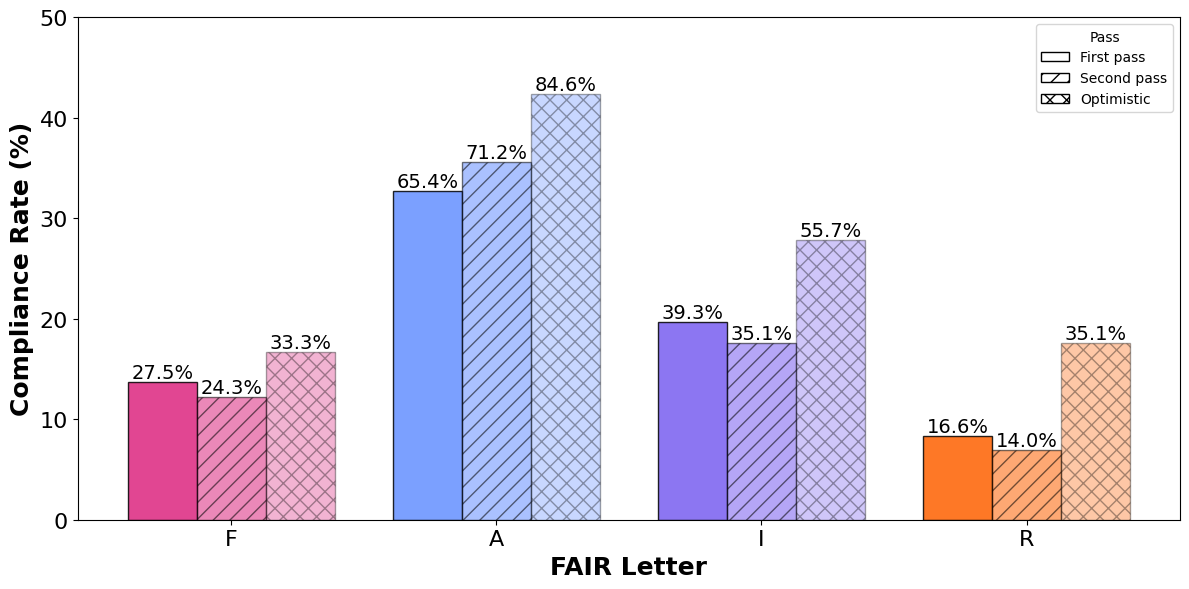

In [1]:
import importlib
import shutil
import pandas as pd
from plotting_scripts.FAIR_compliance import (
    F,
    A,
    I,
    R,
)
from plotting_scripts.repository_stats import repo_stats_main
import plotting_scripts.fair_letter_compliance as fair_letter_compliance
import processing_scripts.optimistic_dataset as optimistic_dataset

importlib.reload(fair_letter_compliance)
importlib.reload(optimistic_dataset)

# One-time PGF/TeX availability check for this run.
tex_candidates = ("pdflatex", "lualatex", "xelatex")
selected_tex_engine = next((tex for tex in tex_candidates if shutil.which(tex)), None)
if selected_tex_engine:
    print(f"PGF export TeX engine detected: {selected_tex_engine}")
else:
    print("PGF export TeX engine detected: none (PGF files will be skipped)")

# Load first/second pass datasets (all papers, then filtered views for standard FAIR plots)
sample_file = "results/FAIR Evaluation Results - First Pass Responses_fixed.csv"
second_sample_file = "results/FAIR Evaluation Results - Second Pass Responses_fixed.csv"

df_first_all = optimistic_dataset.load_pass_dataset(
    sample_file,
    drop_cols=optimistic_dataset.DEFAULT_DROP_COLUMNS,
    artifact_col=optimistic_dataset.ARTIFACT_COLUMN,
    artifacts_only=False,
)
df_second_all = optimistic_dataset.load_pass_dataset(
    second_sample_file,
    drop_cols=optimistic_dataset.DEFAULT_DROP_COLUMNS,
    artifact_col=optimistic_dataset.ARTIFACT_COLUMN,
    artifacts_only=False,
)

df = df_first_all[
    df_first_all[optimistic_dataset.ARTIFACT_COLUMN].astype(str).str.strip().str.lower() == "yes"
]
df_second = df_second_all[
    df_second_all[optimistic_dataset.ARTIFACT_COLUMN].astype(str).str.strip().str.lower() == "yes"
]

# Build optimistic dataset with OR logic across FAIR criteria and merged locations.
all_fair_criteria = F + A + I + R
df_optimistic_all = optimistic_dataset.build_optimistic_dataset(
    first_pass_df=df_first_all,
    second_pass_df=df_second_all,
    fair_criteria=all_fair_criteria,
    artifact_col=optimistic_dataset.ARTIFACT_COLUMN,
    artifacts_only=False,
)
df_optimistic = df_optimistic_all[
    df_optimistic_all[optimistic_dataset.ARTIFACT_COLUMN].astype(str).str.strip().str.lower() == "yes"
]

# Select dataframe to use in single-dataset plots.
plot_dataframes = {
    "first_pass": df,
    "second_pass": df_second,
    "optimistic": df_optimistic,
}

dataset_sizes = optimistic_dataset.get_dataset_size_table(df, df_second, df_optimistic)
print("Dataset sizes (artifact present only):")
print(dataset_sizes.to_string(index=False))
print(f"All-paper sizes -> first: {len(df_first_all)}, second: {len(df_second_all)}, optimistic: {len(df_optimistic_all)}")

selected_dataframe_name = "optimistic"  # choose: first_pass, second_pass, optimistic
plot_df = plot_dataframes[selected_dataframe_name]
print(f"Using plot dataframe: {selected_dataframe_name} ({len(plot_df)} papers)")

# Plot full FAIR compliance by letter for both real passes and optimistic
fair_letter_compliance.plot_fair_letter_compliance(df, df_second, df_optimistic)

Generating FAIR criterion compliance plot...
Saved PNG plot to graphs\fair_criterion_compliance.png
Saved PGF plot to graphs\pgf\fair_criterion_compliance.pgf


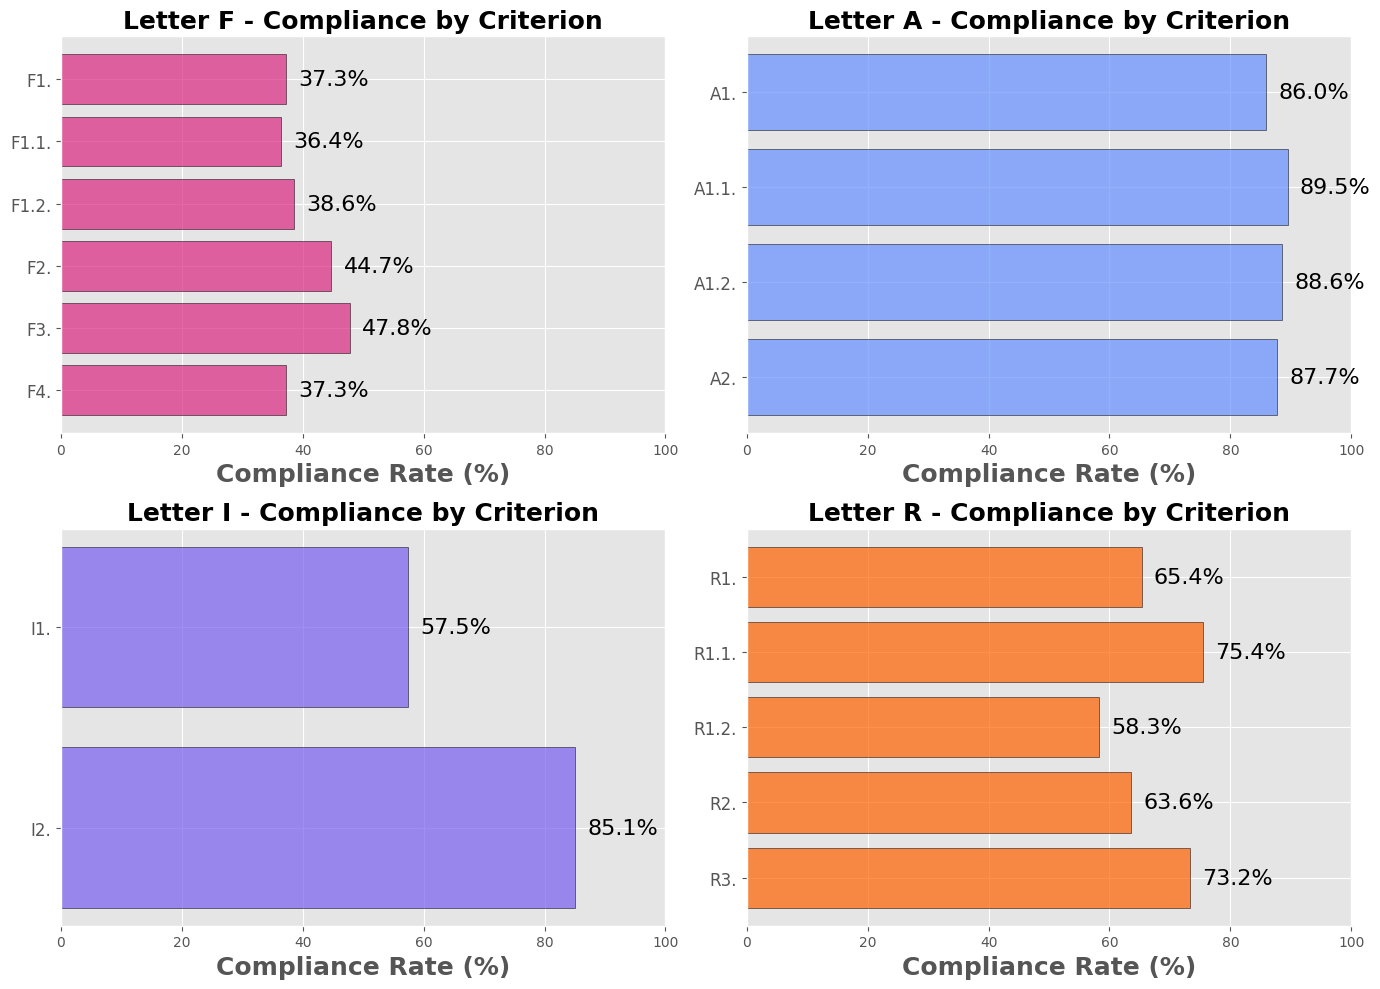

In [2]:
from plotting_scripts.fair_criterion_compliance import main as fair_criterion_main

# Individual Letter Compliance Analysis (choose with selected_dataframe_name in Cell 2)
fair_criterion_main(plot_df, F, A, I, R)

Generating full FAIR compliance plot...


c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\full_fair_compliance.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=FONTSIZE_LABELS)
c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\full_fair_compliance.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\full_fair_compliance.png
Saved PGF plot to graphs\pgf\full_fair_compliance.pgf


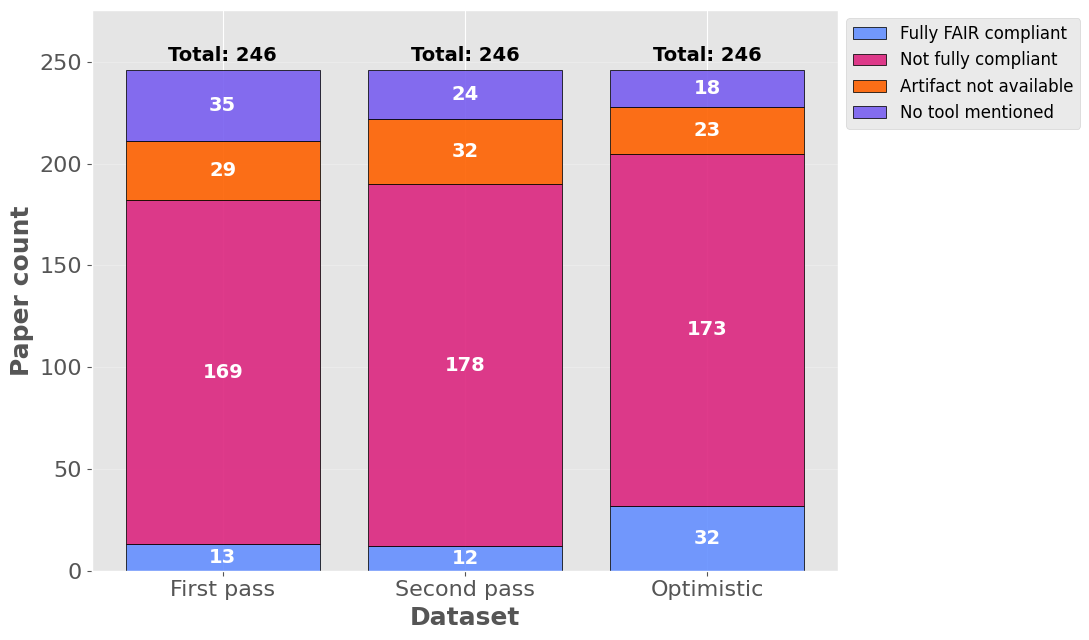

In [3]:
from plotting_scripts.full_fair_compliance import main as full_fair_main

# Full FAIR compliance outcome breakdown across first, second, and optimistic datasets
full_fair_main(df_first_all, df_second_all, df_optimistic_all)

Generating FAIR criteria distribution plot...


c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\fair_criteria_distribution.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\fair_criteria_distribution.png
Saved PGF plot to graphs\pgf\fair_criteria_distribution.pgf


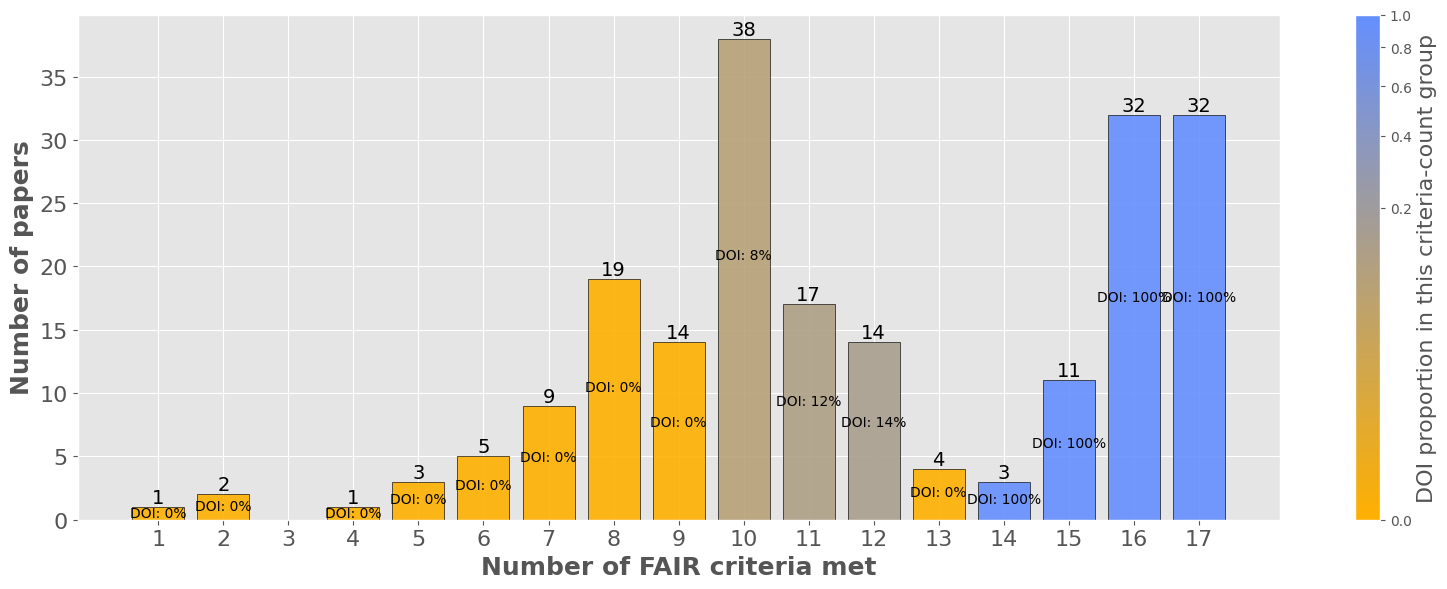

In [4]:
from plotting_scripts.fair_criteria_distribution import main as fair_dist_main

# Distribution of number of FAIR criteria met (1..n)
# Bar colors indicate DOI proportion within each criteria-count group.
# Uses selected_dataframe_name from Cell 2.
fair_dist_main(plot_df, F, A, I, R)

Generating artifact overlap plot...
Papers with tool/repo mentioned: 228 / 246
Artefact cited in paper for findability: 194 / 228
Set-wide average FAIR criteria met: 8.4 / 17
Saved PNG plot to graphs\artifact_overlap.png
Saved PGF plot to graphs\pgf\artifact_overlap.pgf


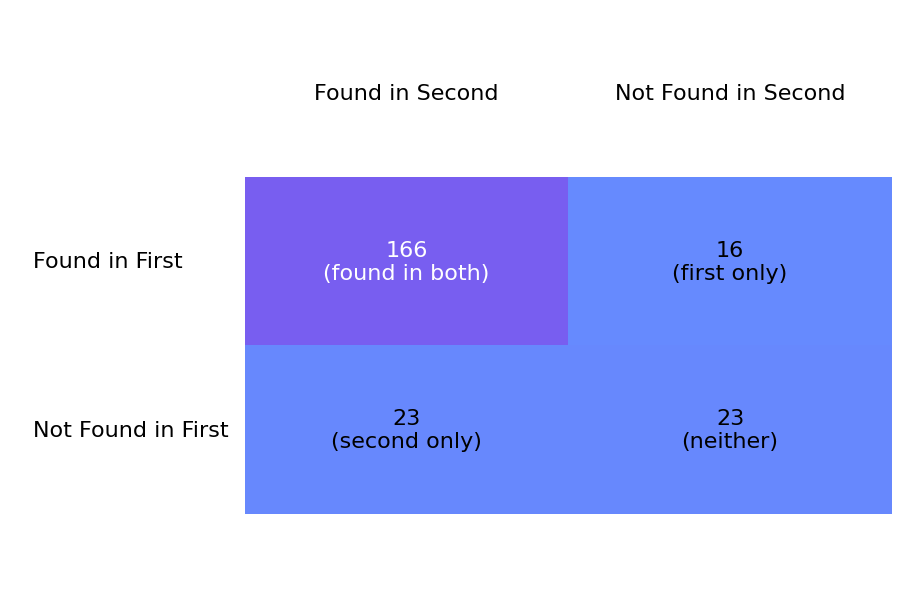

In [5]:
from plotting_scripts.artifact_overlap import main as overlap_main

# Artifact overlap between first and second pass.
# Papers found in only one pass are printed with their location and average FAIR score.
overlap_main(df_first_all, df_second_all, all_fair_criteria)

Generating ACM badge cascade plots...


c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\acm_badge_cascade.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=FONTSIZE_LABELS)
c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\acm_badge_cascade.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\acm_badge_cascade.png
Saved PGF plot to graphs\pgf\acm_badge_cascade.pgf


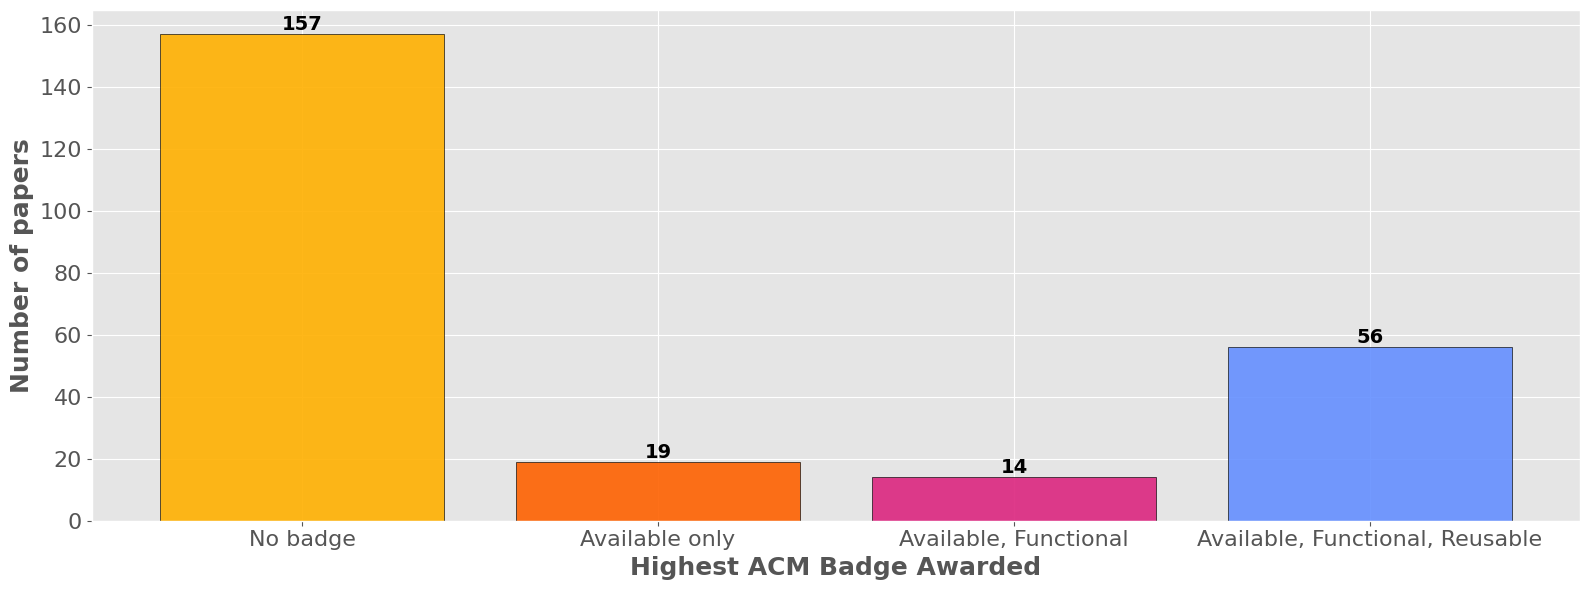

Generating FAIR criteria by badge plot...


c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\acm_badge_cascade.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\fair_criteria_by_badge.png
Saved PGF plot to graphs\pgf\fair_criteria_by_badge.pgf


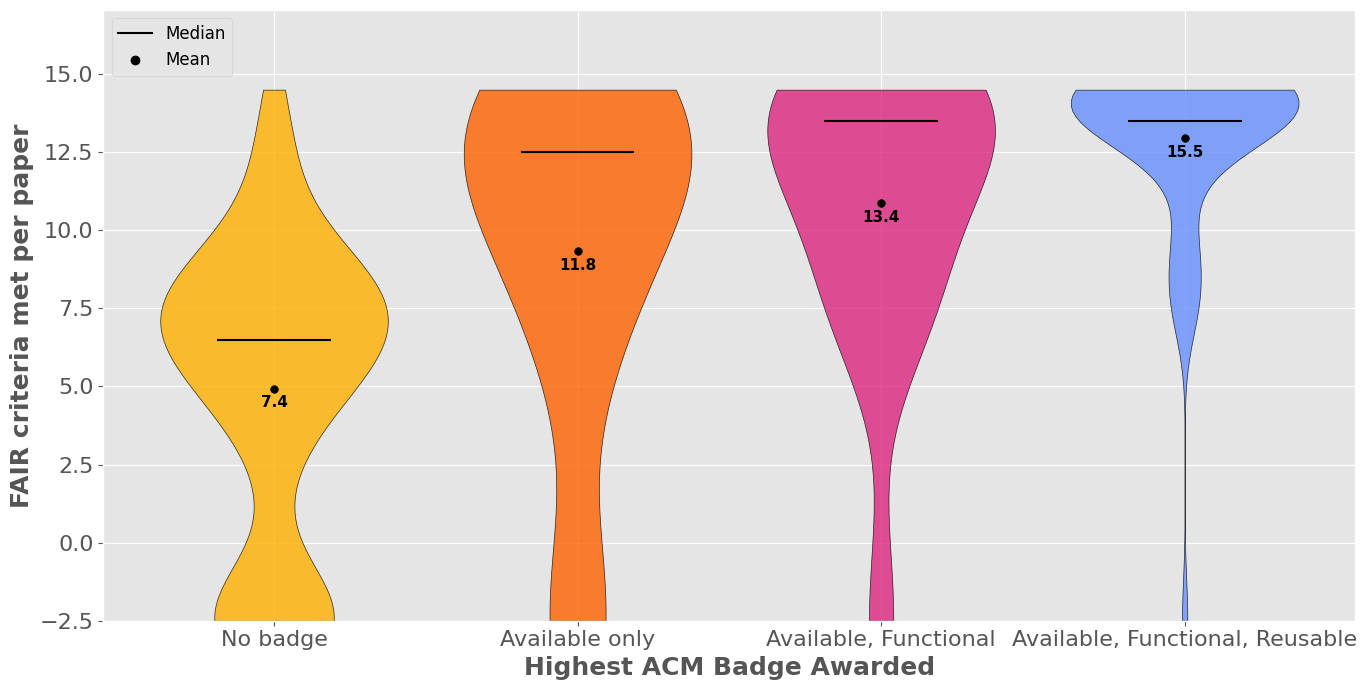

In [6]:
from plotting_scripts.acm_badge_cascade import main as badge_main

# ACM badge compliance cascade and FAIR criteria whisker plots from optimistic conflict-resolved dataset
badge_main(df_optimistic_all, None, df_optimistic_all)

First pass (available papers): {'Zenodo Only': 27, 'GitHub Only': 95, 'Figshare Only': 8, 'Zenodo and GitHub': 34, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 6, 'Google Sites': 2, 'Other': 5}
First pass (unavailable papers): {'Zenodo Only': 0, 'GitHub Only': 4, 'Figshare Only': 0, 'Zenodo and GitHub': 0, 'Figshare and GitHub': 0, 'Anonymous GitHub Only': 3, 'Google Sites': 0, 'Not Found': 22}
Second pass (available papers): {'Zenodo Only': 20, 'GitHub Only': 113, 'Figshare Only': 8, 'Zenodo and GitHub': 30, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 7, 'Google Sites': 2, 'Other': 5}
Second pass (unavailable papers): {'Zenodo Only': 2, 'GitHub Only': 5, 'Figshare Only': 1, 'Zenodo and GitHub': 0, 'Figshare and GitHub': 0, 'Anonymous GitHub Only': 3, 'Google Sites': 0, 'Not Found': 21}
Optimistic (available papers): {'Zenodo Only': 17, 'GitHub Only': 106, 'Figshare Only': 10, 'Zenodo and GitHub': 52, 'Figshare and GitHub': 6, 'Anonymous GitHub Only': 0, 'Google Sites': 2,

c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\repository_stats.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\repository_available_comparison.png
Saved PGF plot to graphs\pgf\repository_available_comparison.pgf


c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\repository_stats.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\repository_unavailable_comparison.png
Saved PGF plot to graphs\pgf\repository_unavailable_comparison.pgf


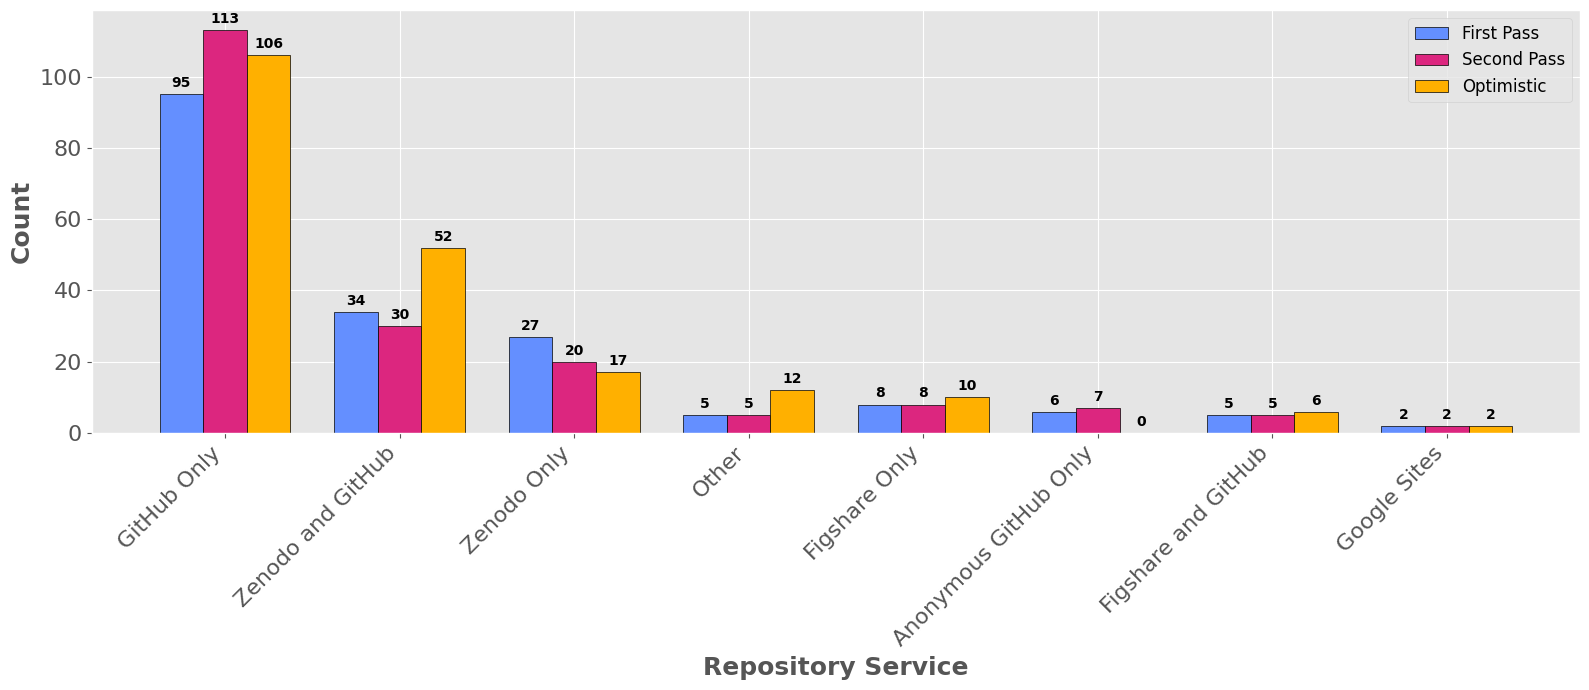

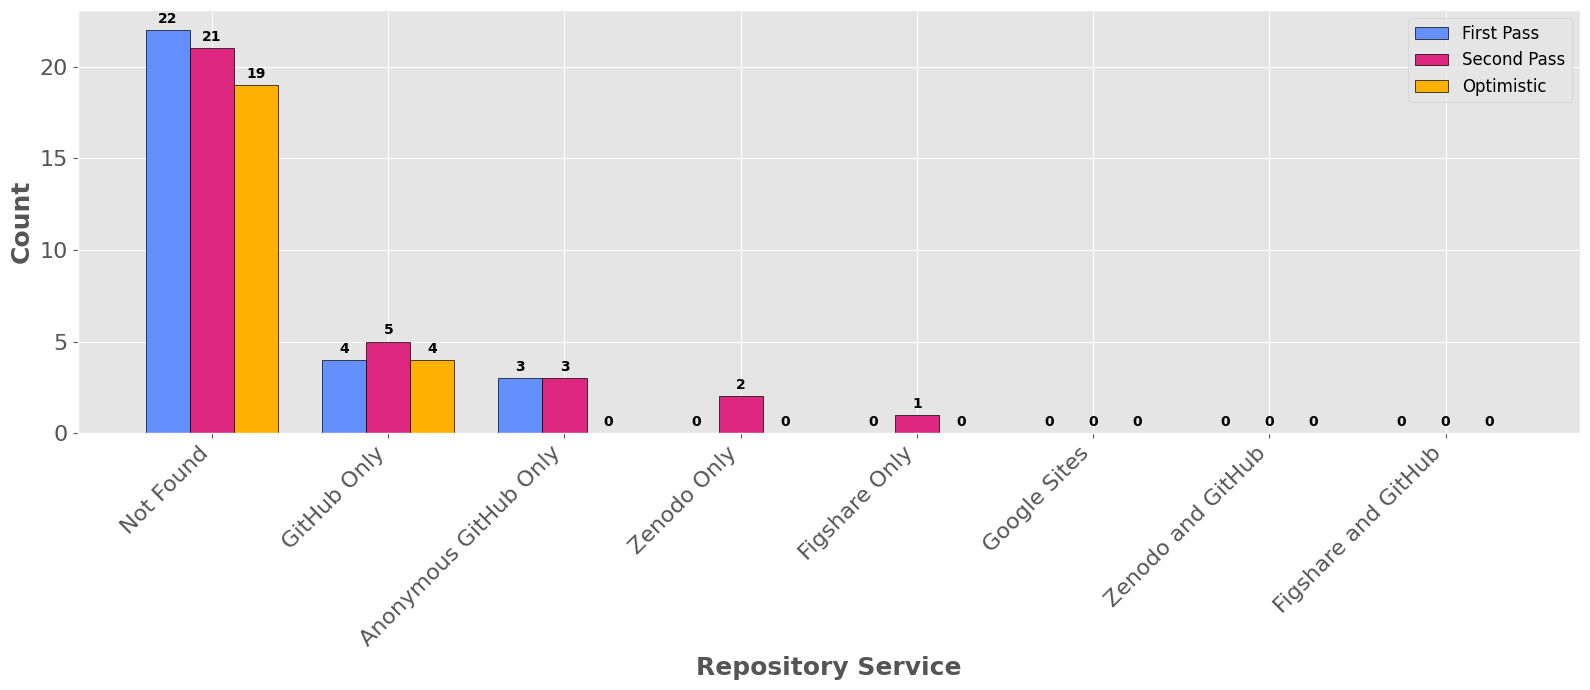

In [7]:
from plotting_scripts.repository_stats import repo_stats_main

# Repository stats from first and second pass datasets
repo_stats_main(df_first_all, df_second_all, df_optimistic_all)

First pass: {'Available': 182, 'Unavailable': 29, 'No Artefact': 35}
Second pass: {'Available': 190, 'Unavailable': 32, 'No Artefact': 24}
Optimistic: {'Available': 205, 'Unavailable': 23, 'No Artefact': 18}


c:\Users\cooki\OneDrive\Uni\Year 5\COM4520\how_fair_is_2026\plotting_scripts\artefact_availability.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=FONTSIZE_LABELS)


Saved PNG plot to graphs\availability_comparison.png
Saved PGF plot to graphs\pgf\availability_comparison.pgf


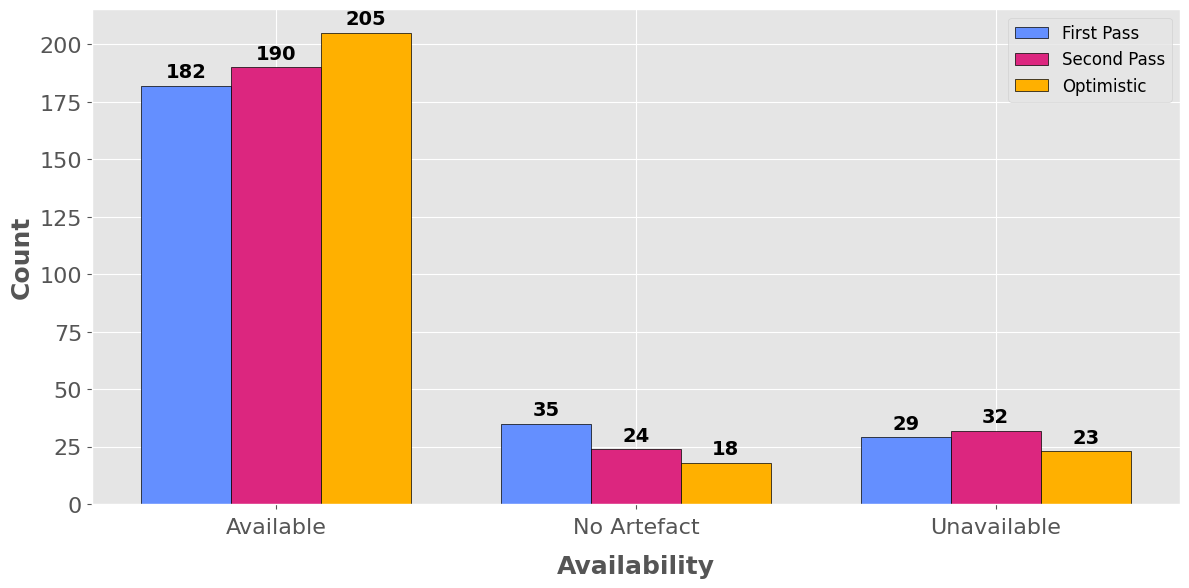

In [8]:
from plotting_scripts.artefact_availability import availability_main

# Availability from first and second pass datasets
availability_main(df_first_all, df_second_all, df_optimistic_all)

In [9]:
from processing_scripts.desirable_criteria import desirable_criteria_main
print("==== FIRST PASS ====")
desirable_criteria_main(df_first_all)

print("==== SECOND PASS ====")
desirable_criteria_main(df_second_all)

print("==== OPTIMISTIC ====")
desirable_criteria_main(df_optimistic_all)

==== FIRST PASS ====
163 out of 246 papers have achieved criterion: Has the software artefact been mentioned or cited in the paper for ease of findability?. (0.66%)
55 out of 246 papers have achieved criterion: Does the software require the use of any 3rd party tools in order to execute it?. (0.22%)
Distribution for Have any containerisation engines / orchestrators been employed in the reuse of the software?
Key: total. Count: 58 out of 246 papers (0.24%). 
Key: Docker. Count: 54 out of 246 papers (0.22%). 
Key: conda. Count: 2 out of 246 papers (0.01%). 
Key: ipnotebook. Count: 2 out of 246 papers (0.01%). 
Distribution for Is the software itself documented well? Which of the following code readability standards have been implemented?
Key: total. Count: 105 out of 246 papers (0.43%). 
Key: Inline comments. Count: 99 out of 246 papers (0.40%). 
Key: Docstrings. Count: 42 out of 246 papers (0.17%). 
Key: Decorators. Count: 1 out of 246 papers (0.00%). 
Key: ipynb file with clear instuct